# 🅿️ Lisbon Parking Analytics
## Phase 1 — Exploratory Data Analysis

**Data source:** EMEL — Lugares de estacionamento na via pública (Histórico)  
**Format:** Shapefile (`.shp`) — includes geometry + attributes  
**Coverage:** Active parking spots as of 2020-09-10  
**License:** Creative Commons CC Zero

---

## 0. Setup

In [1]:
import os
import warnings
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

BASE_DIR = os.path.dirname(os.path.abspath('__file__'))
RAW_DIR = os.path.join(BASE_DIR, '..', 'data', 'raw') + os.sep
PROCESSED_DIR = os.path.join(BASE_DIR, '..', 'data', 'processed') + os.sep

os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

print('✅ Setup complete')
print('RAW_DIR:', RAW_DIR)
print('PROCESSED_DIR:', PROCESSED_DIR)

✅ Setup complete
RAW_DIR: c:\Users\Beatriz Fernandes\Desktop\Data Analytics\For Funsies\ViaVerde\notebooks\..\data\raw\
PROCESSED_DIR: c:\Users\Beatriz Fernandes\Desktop\Data Analytics\For Funsies\ViaVerde\notebooks\..\data\processed\


---
## 1. Load the Shapefile

In [2]:
SHP_PATH = RAW_DIR + 'Lugares_Ativos_20200910.shp'

gdf = gpd.read_file(SHP_PATH)

print(f'Shape:  {gdf.shape}')
print(f'CRS:    {gdf.crs}')
print(f'Columns: {list(gdf.columns)}')

Shape:  (107992, 22)
CRS:    EPSG:27493
Columns: ['IdPosicao', 'CodViaCML', 'Arruamento', 'NumeroPoli', 'NPCompleme', 'Local', 'HorarioEsp', 'Tipologia', 'InfoAdicio', 'InfoAdic_1', 'Produto', 'Tarifa', 'Horario', 'TipoEstaci', 'CodEntidad', 'Entidade', 'NoZona', 'Zona', 'Freguesia', 'Cidade', 'DataInicio', 'geometry']


In [3]:
gdf.head(3)

,IdPosicao,CodViaCML,Arruamento,NumeroPoli,NPCompleme,Local,HorarioEsp,Tipologia,InfoAdicio,InfoAdic_1,Produto,Tarifa,Horario,TipoEstaci,CodEntidad,Entidade,NoZona,Zona,Freguesia,Cidade,DataInicio,geometry
0,503,34656,Estrada da Luz,0,NaN,Estrada da Luz,NaN,Tarifado,NaN,NaN,VerdeRotação,VERDE,2ª A 6ª 9-19H,Rotativo,1,EMEL,23D,São Domingos de Benfica(D),São Domingos de Benfica,Lisboa,2018-04-30,POINT (-90617.767 -100902.732)
1,504,34656,Estrada da Luz,0,NaN,Estrada da Luz,NaN,Tarifado,NaN,NaN,VerdeRotação,VERDE,2ª A 6ª 9-19H,Rotativo,1,EMEL,23D,São Domingos de Benfica(D),São Domingos de Benfica,Lisboa,2018-04-30,POINT (-90614.787 -100906.747)
2,505,34656,Estrada da Luz,0,NaN,Estrada da Luz,NaN,Tarifado,NaN,NaN,VerdeRotação,VERDE,2ª A 6ª 9-19H,Rotativo,1,EMEL,23D,São Domingos de Benfica(D),São Domingos de Benfica,Lisboa,2018-04-30,POINT (-90611.812 -100910.762)


---
## 2. Data Quality

In [4]:
# Null check
null_pct = (gdf.isnull().sum() / len(gdf) * 100).sort_values(ascending=False)
print('Null % per column:')
print(null_pct[null_pct > 0].to_string())

Null % per column:
NPCompleme   97.92
InfoAdic_1   97.70
InfoAdicio   95.78
HorarioEsp   92.77
Local         0.00
Arruamento    0.00


In [5]:
# Data types
print(gdf.dtypes)

IdPosicao              int64
CodViaCML              int64
Arruamento               str
NumeroPoli             int32
NPCompleme               str
Local                    str
HorarioEsp               str
Tipologia                str
InfoAdicio               str
InfoAdic_1               str
Produto                  str
Tarifa                   str
Horario                  str
TipoEstaci               str
CodEntidad               str
Entidade                 str
NoZona                   str
Zona                     str
Freguesia                str
Cidade                   str
DataInicio    datetime64[ms]
geometry            geometry
dtype: object


---
## 3. Explore Key Columns

> After seeing the column names above, we explore the most analytically relevant ones.

In [6]:
# Unique values per column — helps identify categorical fields
for col in gdf.columns:
    if col == 'geometry':
        continue
    n_unique = gdf[col].nunique()
    if n_unique <= 30:
        print(f'\n--- {col} ({n_unique} unique) ---')
        print(gdf[col].value_counts().head(10).to_string())


--- Tipologia (21 unique) ---
Tipologia
Tarifado                        79730
Residente                       10581
Garagem                          7926
Privativo                        2287
Cargas e Descargas               1661
Tarifado + Residente noturno     1450
Moto                             1106
Deficiente                       1048
Tomada e Largada                  657
Táxis                             593

--- Produto (11 unique) ---
Produto
VerdeRotação                          65694
AmarelaRotação                        19598
VerdeExclusiva para residentes        10204
VermelhaRotação                        4389
AmarelaExclusiva para residentes       1919
AmarelaBilhete Diário                  1784
VerdeBilhete Diário                    1764
VerdeRotação + Residente Noturno       1160
BairrosRotação                          644
AmarelaRotação + Residente Noturno      634

--- Tarifa (4 unique) ---
Tarifa
VERDE       78822
AMARELA     23935
VERMELHA     4591
BAIRROS       

---
## 4. Spot Count by Zone / Tariff

> Update the column name below once you've confirmed the zone/tariff column name from Section 3.

In [8]:
# TODO: replace 'ZONE_COL' with the actual column name from Section 3
# e.g. 'TARIFA', 'ZONA', 'COD_ZONA' — whatever appeared above

ZONE_COL = 'Tarifa'  # <- update this

if ZONE_COL in gdf.columns:
    zone_counts = gdf[ZONE_COL].value_counts().reset_index()
    zone_counts.columns = ['zone', 'spot_count']
    print(zone_counts)
else:
    print(f'Column "{ZONE_COL}" not found. Available: {list(gdf.columns)}')

       zone  spot_count
0     VERDE       78822
1   AMARELA       23935
2  VERMELHA        4591
3   BAIRROS         644


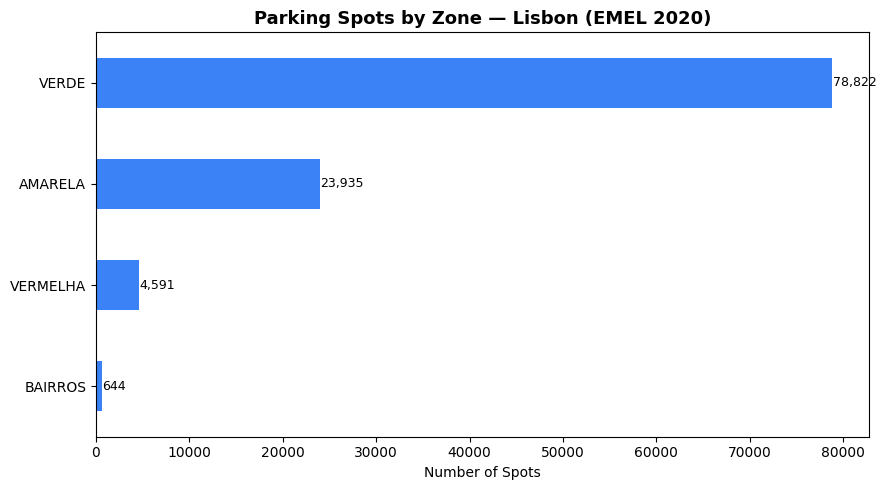

✅ Chart saved


In [9]:
# Bar chart — spots per zone
if ZONE_COL in gdf.columns:
    fig, ax = plt.subplots(figsize=(9, 5))
    zone_counts.sort_values('spot_count', ascending=True).plot(
        kind='barh', x='zone', y='spot_count', ax=ax,
        color='#3b82f6', legend=False
    )
    ax.set_title('Parking Spots by Zone — Lisbon (EMEL 2020)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of Spots')
    ax.set_ylabel('')
    for bar in ax.patches:
        ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                f'{int(bar.get_width()):,}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig(PROCESSED_DIR + 'spots_by_zone.png', dpi=150)
    plt.show()
    print('✅ Chart saved')

---
## 5. Map — Spots by Zone

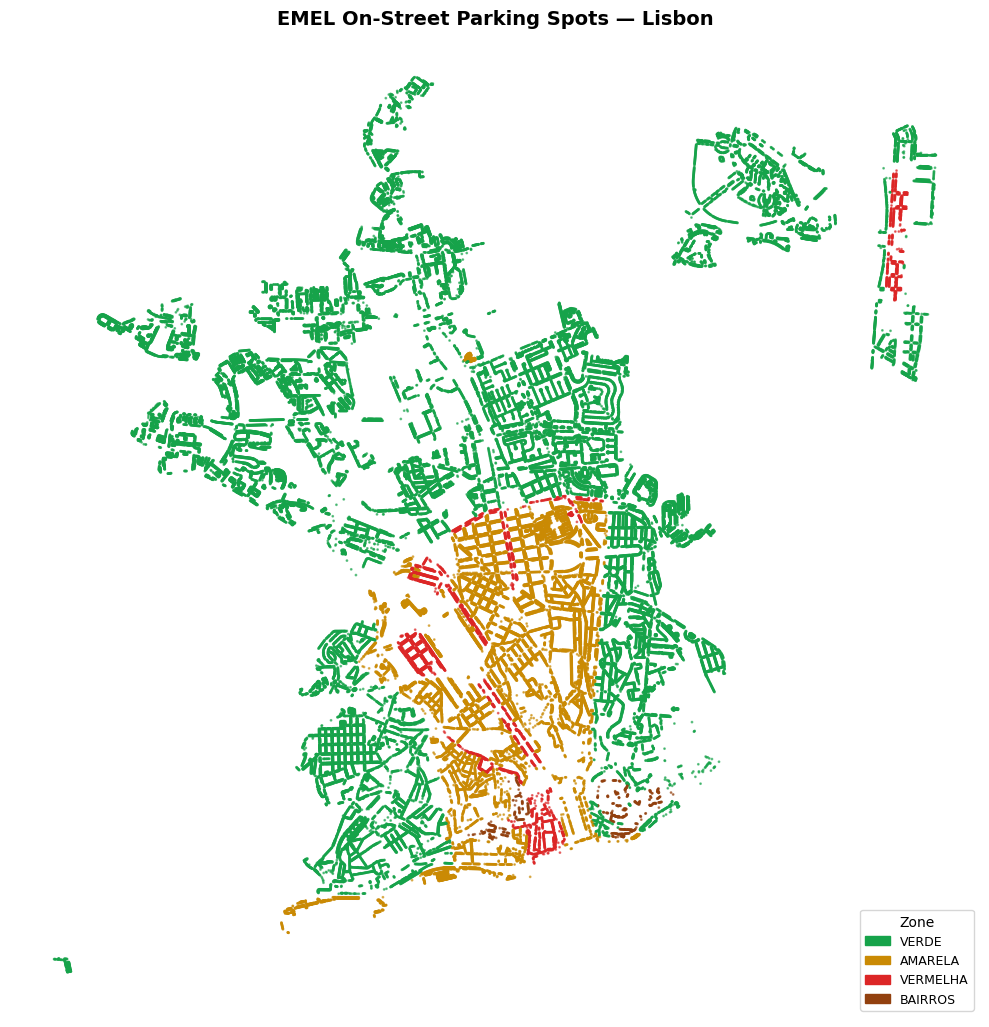

✅ Map saved


In [15]:
# Reproject to WGS84 for plotting
gdf_wgs = gdf.to_crs(epsg=4326)

# Color map — update keys to match actual zone values from Section 3
ZONE_COLORS = {
    'VERDE':     '#16a34a',
    'AMARELA':   '#ca8a04',
    'VERMELHA':  '#dc2626',
    'BAIRROS':   '#92400e',
}
DEFAULT_COLOR = '#94a3b8'

if ZONE_COL in gdf_wgs.columns:
    colors = gdf_wgs[ZONE_COL].map(ZONE_COLORS).fillna(DEFAULT_COLOR)

    fig, ax = plt.subplots(figsize=(10, 12))
    gdf_wgs.plot(ax=ax, color=colors, markersize=1, alpha=0.6)

    patches = [mpatches.Patch(color=v, label=k) for k, v in ZONE_COLORS.items()]
    ax.legend(handles=patches, title='Zone', loc='lower right', fontsize=9)
    ax.set_title('EMEL On-Street Parking Spots — Lisbon', fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(PROCESSED_DIR + 'spots_map.png', dpi=150)
    plt.show()
    print('✅ Map saved')
else:
    print(f'Update ZONE_COL — current value "{ZONE_COL}" not found in columns')

---
## 6. EMEL Financial Reference (2024 Annual Report)

In [11]:
emel_financials = pd.DataFrame([
    {'year': 2024, 'stream': 'On-street metered parking', 'revenue_eur': 25_700_000, 'notes': '102,526 spots across 21 parishes'},
    {'year': 2024, 'stream': 'Off-street garages & lots',  'revenue_eur': 14_600_000, 'notes': '36 facilities — estimated from total'},
    {'year': 2024, 'stream': 'Parking fines',              'revenue_eur':  7_200_000, 'notes': '190,952 fines · avg €37.92 · 100% retained from 2024'},
    {'year': 2024, 'stream': 'Clamps, tows & other',       'revenue_eur':  6_571_000, 'notes': 'Estimated remainder'},
    {'year': 2024, 'stream': 'Total operating revenue',    'revenue_eur': 54_071_000, 'notes': 'EMEL Relatório e Contas 2024'},
])
emel_financials['revenue_m'] = (emel_financials['revenue_eur'] / 1_000_000).round(2)

emel_financials[['stream','revenue_m','notes']]

,stream,revenue_m,notes
0,On-street metered parking,25.70,"102,526 spots across 21 parishes"
1,Off-street garages & lots,14.60,36 facilities — estimated from total
2,Parking fines,7.20,"190,952 fines · avg €37.92 · 100% retained fro..."
3,"Clamps, tows & other",6.57,Estimated remainder
4,Total operating revenue,54.07,EMEL Relatório e Contas 2024


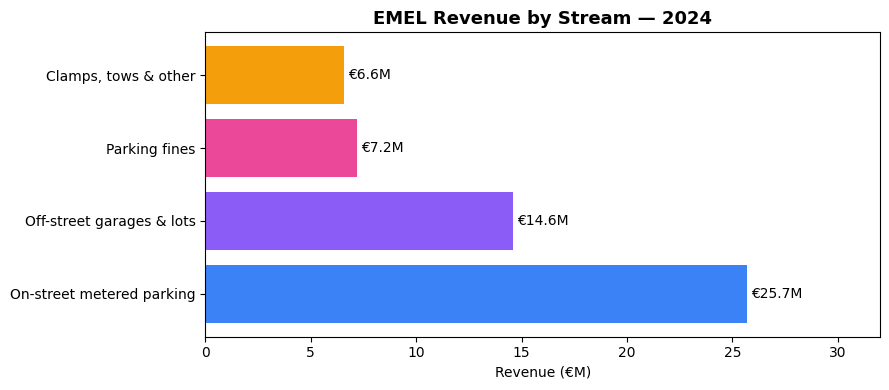

✅ Chart saved


In [12]:
df_2024 = emel_financials[emel_financials['stream'] != 'Total operating revenue'].copy()

colors = ['#3b82f6', '#8b5cf6', '#ec4899', '#f59e0b']
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(df_2024['stream'], df_2024['revenue_m'], color=colors)
ax.set_xlabel('Revenue (€M)')
ax.set_title('EMEL Revenue by Stream — 2024', fontsize=13, fontweight='bold')
for bar in bars:
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'€{bar.get_width():.1f}M', va='center', fontsize=10)
ax.set_xlim(0, 32)
plt.tight_layout()
plt.savefig(PROCESSED_DIR + 'emel_revenue_breakdown.png', dpi=150)
plt.show()
print('✅ Chart saved')

---
## 7. Save Processed Outputs

In [13]:
# Save spots as CSV (without geometry) for SQL import
gdf_wgs.drop(columns='geometry').to_csv(PROCESSED_DIR + 'emel_spots.csv', index=False)

# Save financials
emel_financials.to_csv(PROCESSED_DIR + 'emel_financials.csv', index=False)

print('✅ emel_spots.csv saved')
print('✅ emel_financials.csv saved')
print(f'   Spots: {len(gdf_wgs):,} rows')

✅ emel_spots.csv saved
✅ emel_financials.csv saved
   Spots: 107,992 rows


---
## 8. Summary & Next Steps

### Outputs from Phase 1
| File | Description |
|---|---|
| `data/processed/emel_spots.csv` | All active spots with attributes — ready for SQL |
| `data/processed/emel_financials.csv` | Revenue reference table from 2024 annual report |
| `data/processed/spots_by_zone.png` | Bar chart — spot count per zone |
| `data/processed/spots_map.png` | Map — all spots coloured by zone |

### Phase 2 — SQL (next)
- Design schema: `spots`, `zones`, `financials`
- Load CSVs into MySQL
- Analytical queries: revenue per zone, spots per parish, tariff distribution